**Análisis Exploratorio de la Calidad del Aire: Dióxido de Nitrógeno (NO2) en Montana (2022 y 2023)**

---

1. Importamos paquetes

In [ ]:
import numpy as np                  # Cálculos numéricos y manejo de arreglos/matrices
import pandas as pd                 # Organizar, limpiar y analizar datos en forma de tablas
import matplotlib.pyplot as plt     # Crear Gráficos
import seaborn as sns               # Crear gráficos estadísticos más elaborados y visualmente agradables
%matplotlib inline

2. Importamos el conjunto de datos

In [ ]:
df = pd.read_csv("/ad_viz_plotval_data_2022_2023.csv")
df.head()  # vemos los 5 primeros datos en el data frame

,Date,Source,Site ID,POC,Daily Max 1-hour NO2 Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,...,AQS Parameter Description,Method Code,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,01/01/2022,AQS,300170005,1,24,ppb,23,Miles City - Pines Hills,24,100.0,...,Nitrogen dioxide (NO2),574,NaN,NaN,30,Montana,17,Custer,46.411389,-105.812778
1,01/02/2022,AQS,300170005,1,30,ppb,28,Miles City - Pines Hills,24,100.0,...,Nitrogen dioxide (NO2),574,NaN,NaN,30,Montana,17,Custer,46.411389,-105.812778
2,01/03/2022,AQS,300170005,1,25,ppb,24,Miles City - Pines Hills,24,100.0,...,Nitrogen dioxide (NO2),574,NaN,NaN,30,Montana,17,Custer,46.411389,-105.812778
3,01/04/2022,AQS,300170005,1,24,ppb,23,Miles City - Pines Hills,21,88.0,...,Nitrogen dioxide (NO2),574,NaN,NaN,30,Montana,17,Custer,46.411389,-105.812778
4,01/05/2022,AQS,300170005,1,21,ppb,20,Miles City - Pines Hills,24,100.0,...,Nitrogen dioxide (NO2),574,NaN,NaN,30,Montana,17,Custer,46.411389,-105.812778


3. Consultar información básica sobre el conjunto de datos

In [ ]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 21 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Date                                730 non-null    object 
 1   Source                              730 non-null    object 
 2   Site ID                             730 non-null    int64  
 3   POC                                 730 non-null    int64  
 4   Daily Max 1-hour NO2 Concentration  730 non-null    int64  
 5   Units                               730 non-null    object 
 6   Daily AQI Value                     730 non-null    int64  
 7   Local Site Name                     730 non-null    object 
 8   Daily Obs Count                     730 non-null    int64  
 9   Percent Complete                    730 non-null    float64
 10  AQS Parameter Code                  730 non-null    int64  
 11  AQS Parameter Description           730 non-n

4. Limpieza y preparación de los datos

In [ ]:
# Convertimos la columna Date a formato de fecha
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')

# Extraemos variables temporales que pueden influir en la concentración de NO2
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek'] = df['Date'].dt.dayofweek  # 0 = Lunes ... 6 = Domingo

# Nos quedamos solo con las columnas relevantes para el análisis
# (se descartan columnas constantes o sin información útil para esta estación)
df = df[['Year', 'Month', 'Day', 'DayOfWeek', 'Daily Obs Count', 'Percent Complete',
         'Daily Max 1-hour NO2 Concentration']]

# Renombramos columnas para que sean más fáciles de referenciar en el código
df = df.rename(columns={
    'Daily Obs Count': 'Obs_Count',
    'Percent Complete': 'Percent_Complete',
    'Daily Max 1-hour NO2 Concentration': 'NO2_Max'
})

df.head()

,Year,Month,Day,DayOfWeek,Obs_Count,Percent_Complete,NO2_Max
0,2022,1,1,5,24,100.0,24
1,2022,1,2,6,24,100.0,30
2,2022,1,3,0,24,100.0,25
3,2022,1,4,1,21,88.0,24
4,2022,1,5,2,24,100.0,21


5. Resumen de estadísticas descriptivas

In [ ]:
df.describe().round(2)

,Year,Month,Day,DayOfWeek,Obs_Count,Percent_Complete,NO2_Max
count,730.0,730.00,730.00,730.00,730.00,730.00,730.00
mean,2022.5,6.53,15.72,3.01,23.53,98.06,10.47
std,0.5,3.45,8.80,2.00,1.54,6.37,6.37
min,2022.0,1.00,1.00,0.00,10.00,42.00,0.00
25%,2022.0,4.00,8.00,1.00,24.00,100.00,6.00
50%,2022.5,7.00,16.00,3.00,24.00,100.00,9.00
75%,2023.0,10.00,23.00,5.00,24.00,100.00,14.00
max,2023.0,12.00,31.00,6.00,24.00,100.00,35.00


6. Nombres de las características

In [ ]:
df.columns

Index(['Year', 'Month', 'Day', 'DayOfWeek', 'Obs_Count', 'Percent_Complete',
       'NO2_Max'],
      dtype='object')

7. Las relaciones entre todas las variables

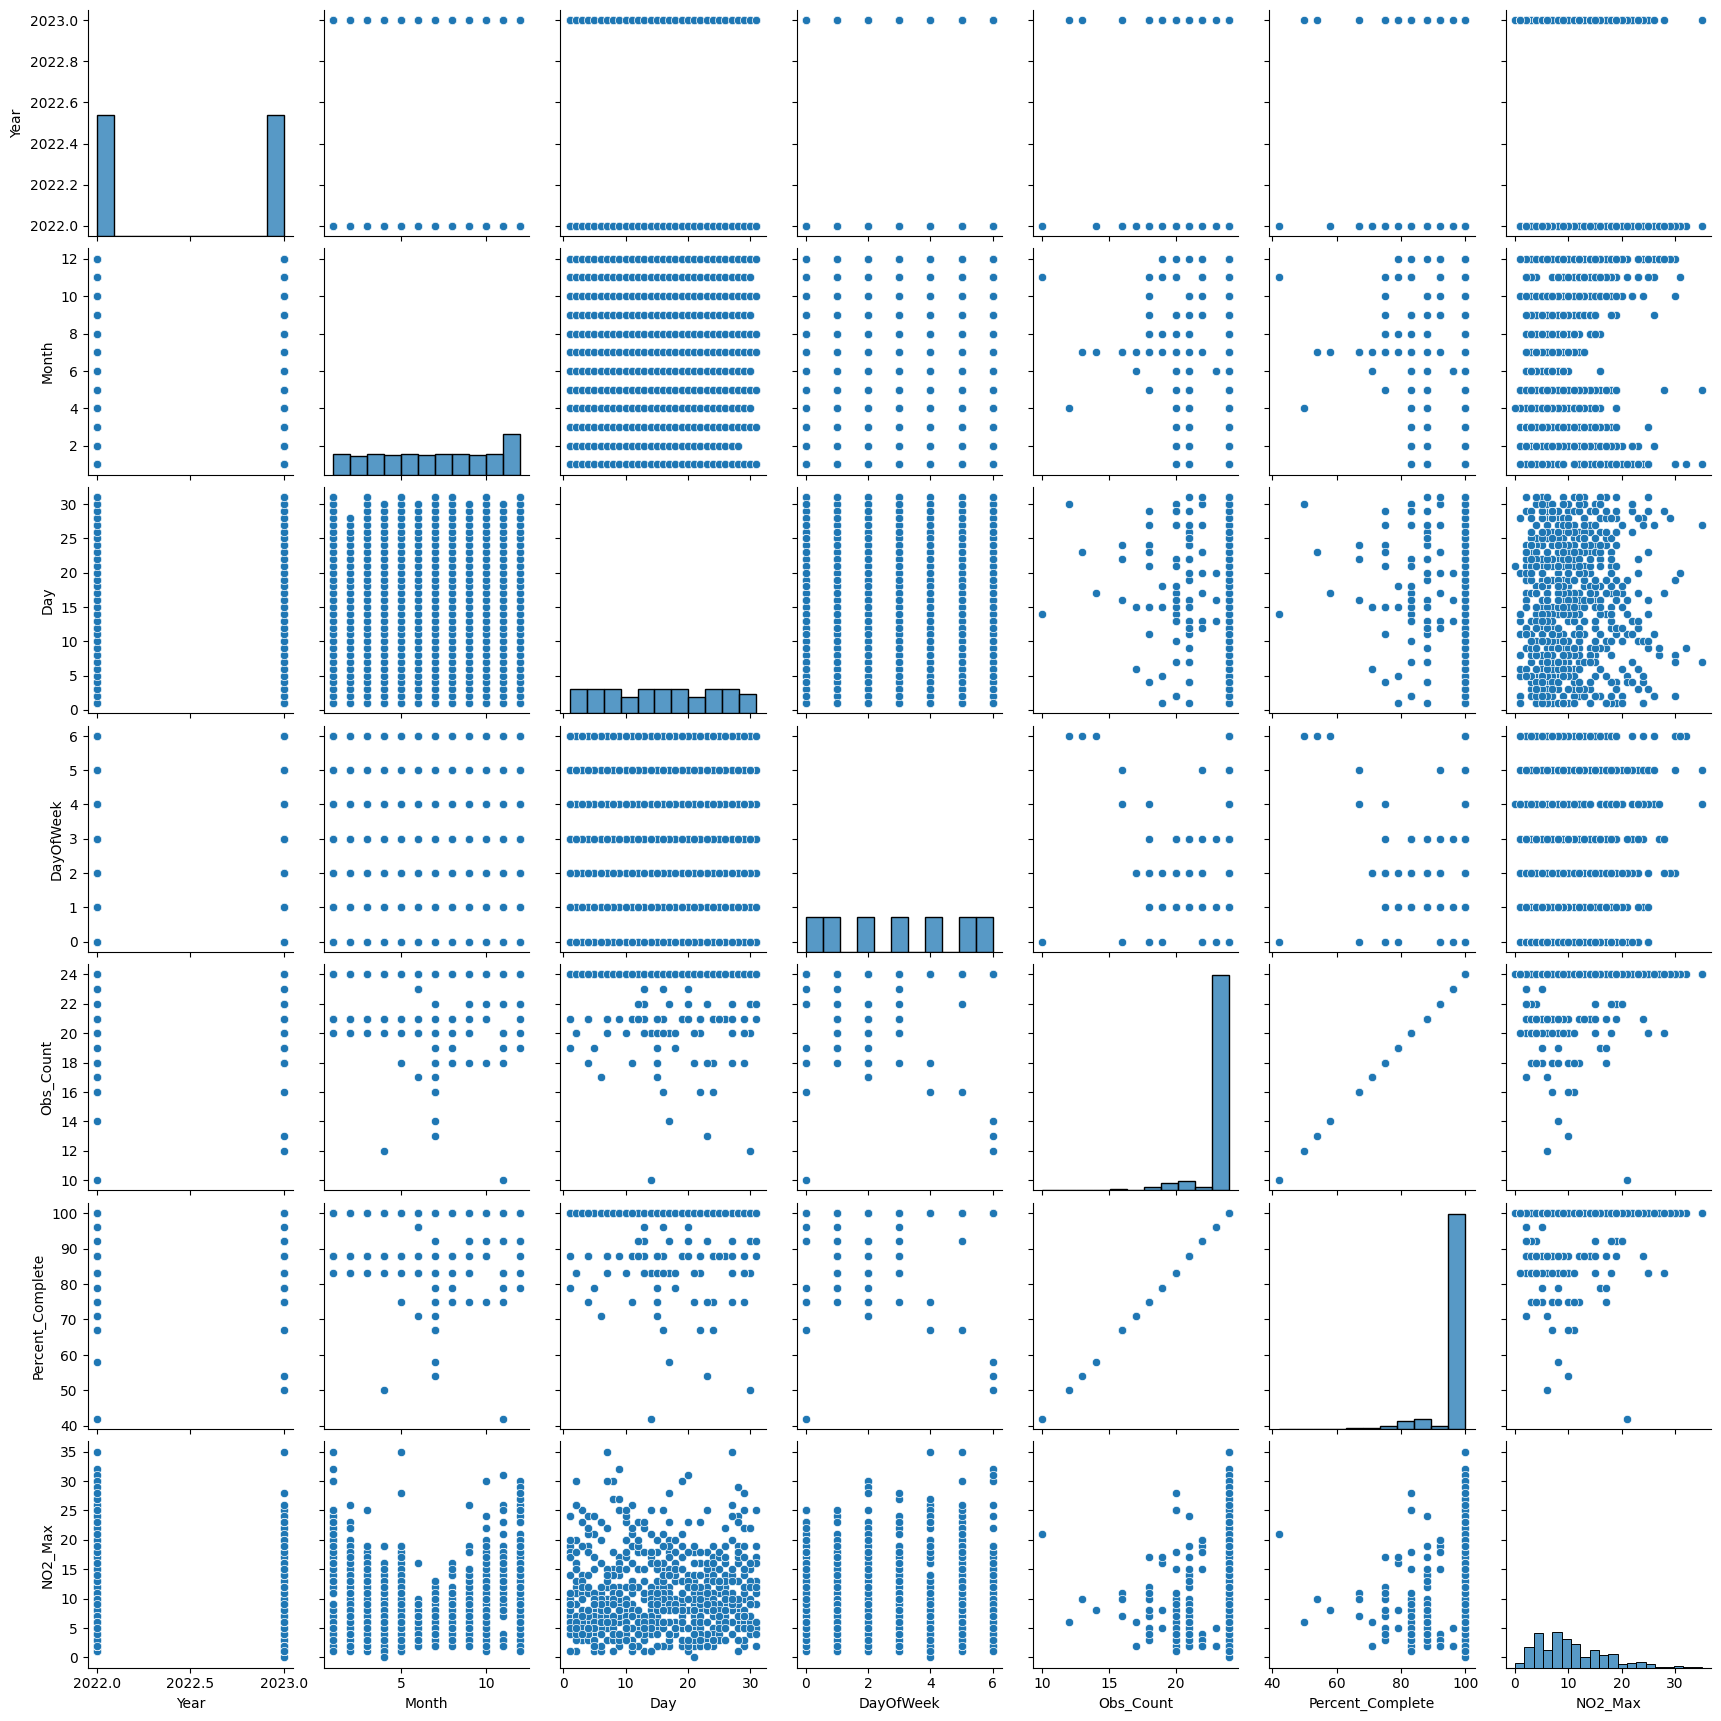

In [ ]:
sns.pairplot(df)

8. Distribución de la concentración máxima diaria de NO2

'Histograma: ¿Cómo se distribuyen los datos por intervalos?'

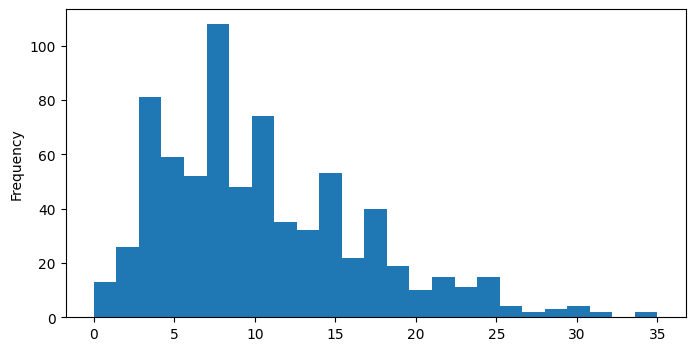

In [ ]:
# Histograma en 25 intervalos
df['NO2_Max'].plot.hist(bins=25, figsize=(8,4))

'''Histograma: ¿Cómo se distribuyen los datos por intervalos?'''

'Densidad: ¿Dónde están concentrados los datos?'

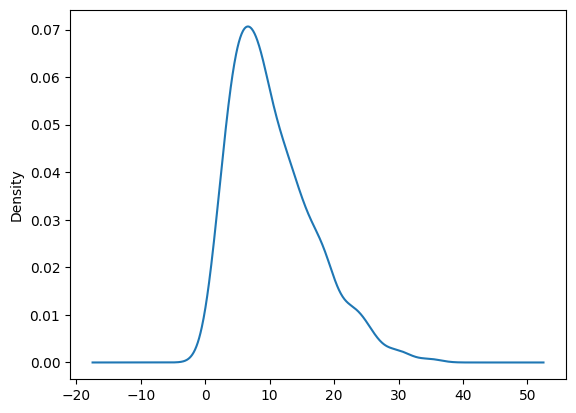

In [ ]:
df['NO2_Max'].plot.density()

'''Densidad: ¿Dónde están concentrados los datos?'''

9. Matriz de correlación y heatmap

In [ ]:
# Selecciona solo las columnas con valores numéricos
numeric_df = df.select_dtypes(include=[np.number])

# Cálculo de la correlación
numeric_df.corr().round(4)

,Year,Month,Day,DayOfWeek,Obs_Count,Percent_Complete,NO2_Max
Year,1.0000,0.0000,0.0000,0.0007,0.0259,0.0265,-0.0241
Month,0.0000,1.0000,0.0119,0.0068,-0.0408,-0.0417,0.0047
Day,0.0000,0.0119,1.0000,-0.0108,-0.0545,-0.0541,-0.0063
DayOfWeek,0.0007,0.0068,-0.0108,1.0000,0.1416,0.1396,0.0311
Obs_Count,0.0259,-0.0408,-0.0545,0.1416,1.0000,0.9998,0.0439
Percent_Complete,0.0265,-0.0417,-0.0541,0.1396,0.9998,1.0000,0.0432
NO2_Max,-0.0241,0.0047,-0.0063,0.0311,0.0439,0.0432,1.0000


<Axes: >

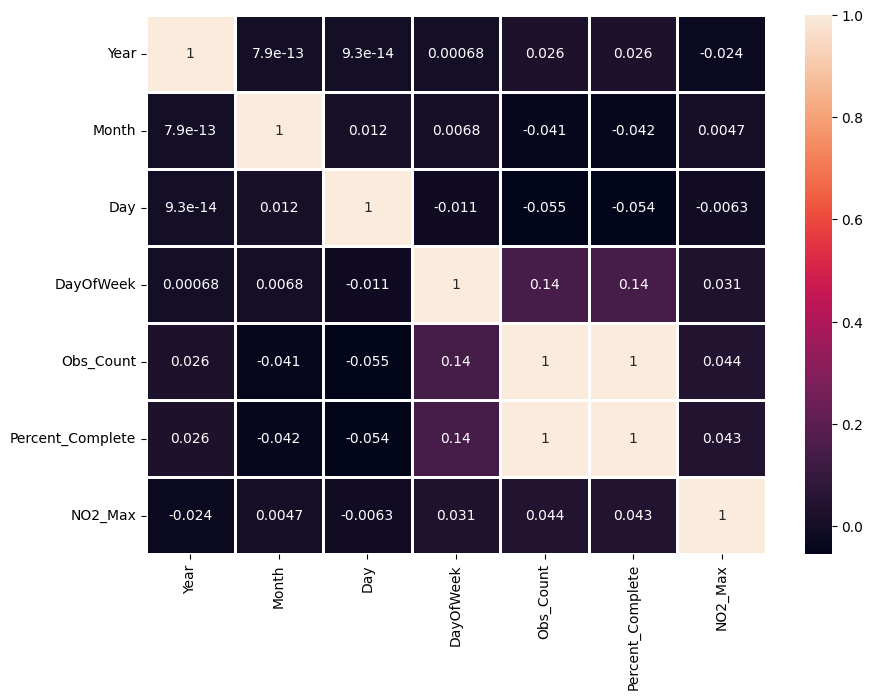

In [ ]:
# Mapa de color de correlaciones
plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(), annot=True, linewidths=2)

10. Conjunto de características y variables

In [ ]:
l_column = list(df.columns) # Haciendo la lista de columnas
len_feature = len(l_column)  # Longitud de la lista de vectores de columna
l_column

['Year',
 'Month',
 'Day',
 'DayOfWeek',
 'Obs_Count',
 'Percent_Complete',
 'NO2_Max']

11. Regresión

In [ ]:
X = df[l_column[0:len_feature-1]]   # Variables predictoras
Y = df[l_column[len_feature-1]]     # Variable objetivo: NO2_Max
X.head()

,Year,Month,Day,DayOfWeek,Obs_Count,Percent_Complete
0,2022,1,1,5,24,100.0
1,2022,1,2,6,24,100.0
2,2022,1,3,0,24,100.0
3,2022,1,4,1,21,88.0
4,2022,1,5,2,24,100.0


In [ ]:
Y.head()

,NO2_Max
0,24
1,30
2,25
3,24
4,21


12. Definimos entrenamiento - prueba

In [ ]:
from sklearn.model_selection import train_test_split
# Divide datos en entrenamiento y prueba

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.3, random_state=123
)
# 70%: entrenamiento
# 30%: prueba
# random_state=123 >> Haz la división aleatoria, pero reproducible

13. Ajuste y entrenamiento del modelo

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn import metrics

# machine learning
# modelo: regresión lineal
# métricas: ¿Qué tan buenas son las predicciones?

In [ ]:
lm = LinearRegression() # Creando un objeto de Regresión Lineal 'lm'

In [ ]:
lm.fit(X_train, Y_train) # Ajustar y entrenar

LinearRegression()

In [ ]:
# Verificamos la intercepción
print("El término de intersección del modelo lineal:", lm.intercept_)

El término de intersección del modelo lineal: 1566.830328071976


In [ ]:
# Verificamos el modelo lineal
print("Los coeficientes del modelo lineal:", lm.coef_)

Los coeficientes del modelo lineal: [-0.77270081  0.01487516 -0.01584314  0.03345807  3.53594468 -0.7788252 ]


In [ ]:
cdf = pd.DataFrame(data=lm.coef_, index=X_train.columns, columns=["Coefficients"])
cdf

,Coefficients
Year,-0.772701
Month,0.014875
Day,-0.015843
DayOfWeek,0.033458
Obs_Count,3.535945
Percent_Complete,-0.778825


14. Cálculo de errores estándar y estadística t para los coeficientes

In [ ]:
n = X_train.shape[0]   # Cantidad de datos de entrenamiento
k = X_train.shape[1]   # Cantidad de variables predictoras
dfN = n - k             # grados de libertad
train_pred = lm.predict(X_train)  # Obtener predicciones

# calculamos el error: R al cuadrado
train_error = np.square(train_pred - Y_train)
sum_error = np.sum(train_error)

se = [0] * k
for i in range(k):
    r = (sum_error / dfN)
    # Cuánto varía el valor respecto a su promedio
    # Selecciona la variable i-ésima y calcula su promedio
    r = r / np.sum(np.square(X_train[list(X_train.columns)[i]] - X_train[list(X_train.columns)[i]].mean()))
    se[i] = np.sqrt(r)  # Cálculo del error estándar

cdf['Standard Error'] = se
cdf['t_statistic'] = cdf['Coefficients'] / cdf['Standard Error']
# ¿El coef. es grande en comparación con la incertidumbre que tiene?
# ¿Está alejado de 0 respecto a su error estándar?
cdf

,Coefficients,Standard Error,t_statistic
Year,-0.772701,0.589794,-1.310119
Month,0.014875,0.083655,0.177816
Day,-0.015843,0.033847,-0.468086
DayOfWeek,0.033458,0.147875,0.226259
Obs_Count,3.535945,0.203842,17.346512
Percent_Complete,-0.778825,0.049028,-15.885331


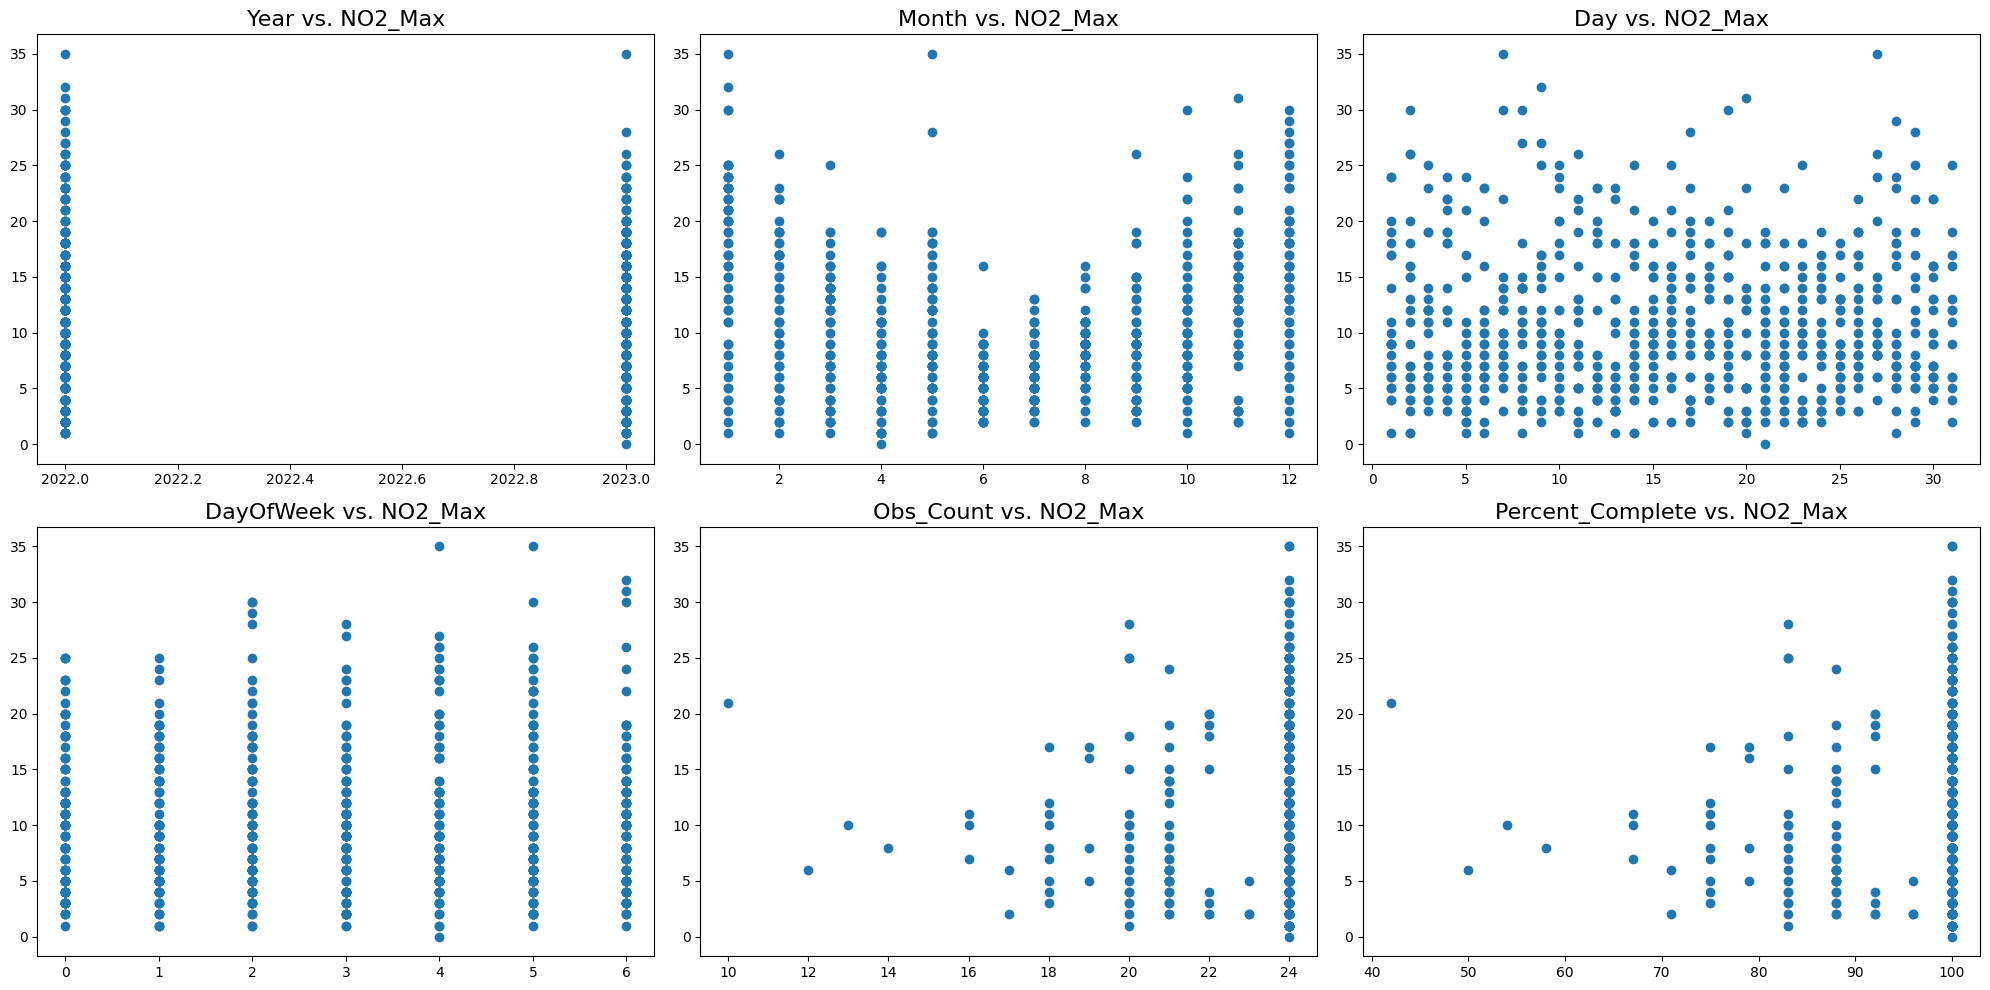

In [ ]:
l = list(cdf.index)

from matplotlib import gridspec
fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 3)  # 6 predictores: Year, Month, Day, DayOfWeek, Obs_Count, Percent_Complete

for i, col in enumerate(l):
    ax = plt.subplot(gs[i])
    ax.scatter(df[col], df['NO2_Max'])
    ax.set_title(col + " vs. NO2_Max", fontdict={'fontsize': 16})

plt.tight_layout()

15. Matrices de evaluación de predicción, estimación de error y regresión

In [ ]:
predictions = lm.predict(X_test)
print("Tipo del objeto predicho:", type(predictions))
print("Tamaño del objeto predicho:", predictions.shape)

Tipo del objeto predicho: <class 'numpy.ndarray'>
Tamaño del objeto predicho: (219,)


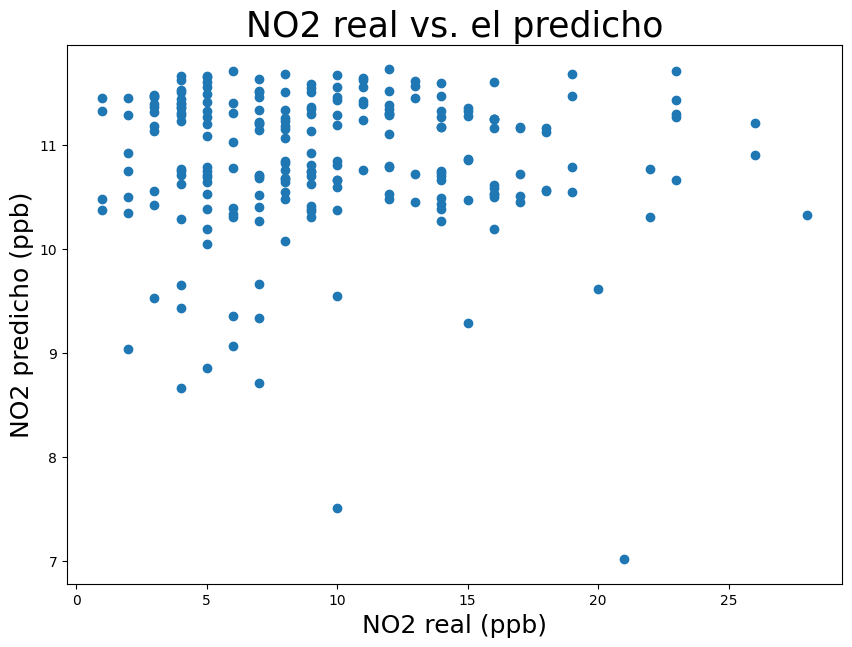

In [ ]:
# Diagrama de dispersión

'''Meta: Datos caen en una línea recta de 45°'''

plt.figure(figsize=(10,7))
plt.title("NO2 real vs. el predicho", fontsize=25)
plt.xlabel("NO2 real (ppb)", fontsize=18)
plt.ylabel("NO2 predicho (ppb)", fontsize=18)
plt.scatter(x=Y_test, y=predictions)

<Axes: title={'center': 'Histograma de residuos para verificar la normalidad'}, xlabel='Residuos', ylabel='Densidad del kernel'>

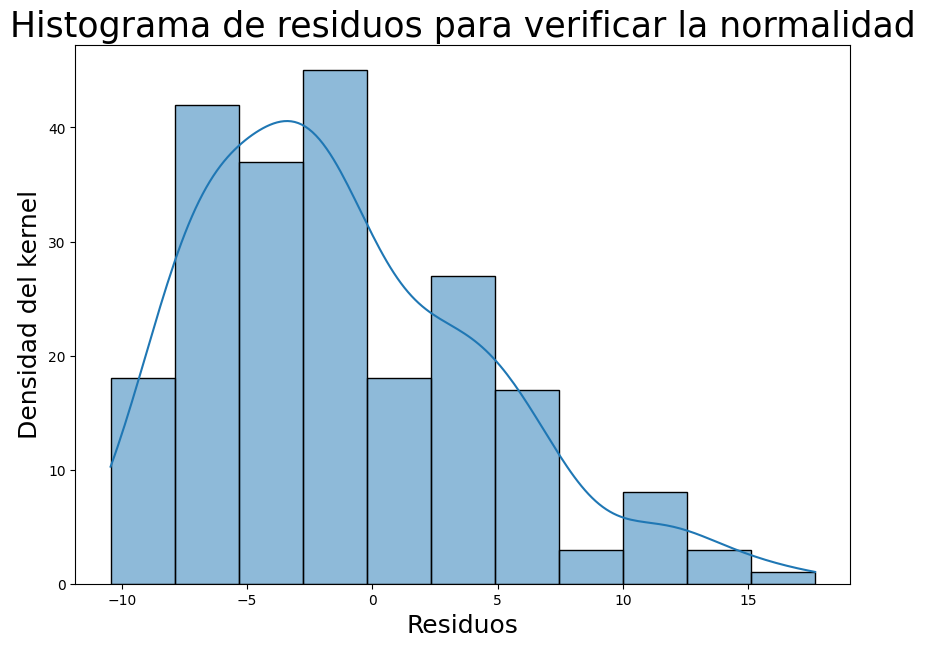

In [ ]:
plt.figure(figsize=(10, 7))
plt.title("Histograma de residuos para verificar la normalidad", fontsize=25)
plt.xlabel("Residuos", fontsize=18)
plt.ylabel("Densidad del kernel", fontsize=18)
sns.histplot((Y_test - predictions), kde=True)

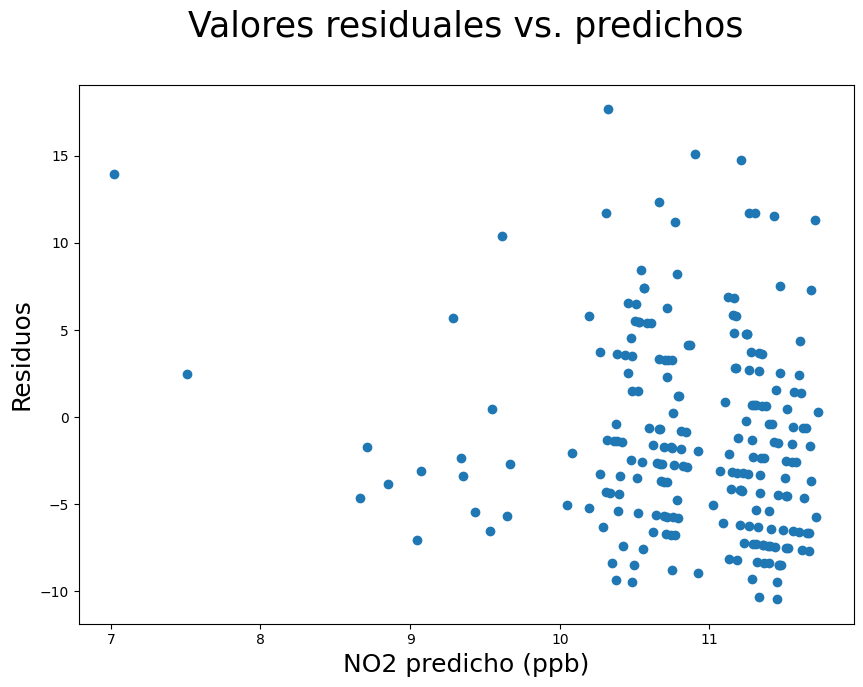

In [ ]:
# Diagrama de dispersión (Homoscedasticidad)

'''La varianza de los errores es aprox. constante a lo largo de las predicciones'''

plt.figure(figsize=(10,7))
plt.title("Valores residuales vs. predichos\n", fontsize=25)
plt.xlabel("NO2 predicho (ppb)", fontsize=18)
plt.ylabel("Residuos", fontsize=18)
plt.scatter(x=predictions, y=Y_test - predictions)

16. Árbol de decisión

In [ ]:
from sklearn import tree

# Creación del modelo
tree_model = tree.DecisionTreeRegressor(max_depth=5, random_state=10)

# Ajuste del modelo con los mismos datos de entrenamiento usados en la regresión lineal
tree_model.fit(X_train, Y_train)

DecisionTreeRegressor(max_depth=5, random_state=10)

Error cuadrático medio (MSE): 31.47404074510752


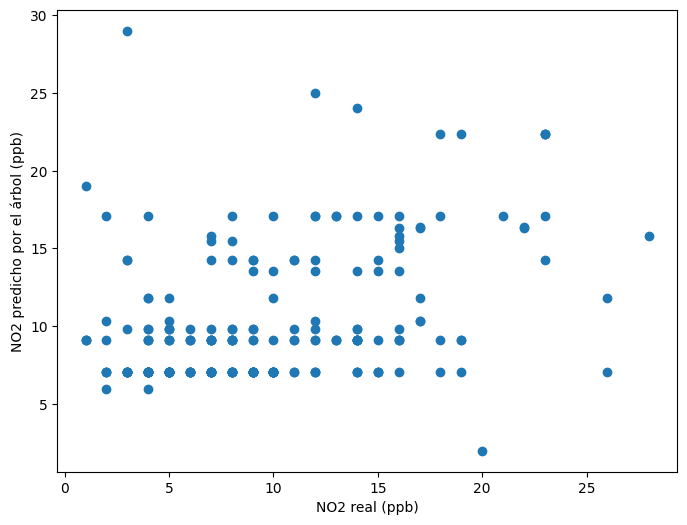

In [ ]:
from sklearn import metrics

# Hacemos predicciones
tree_pred = tree_model.predict(X_test)
plt.figure(figsize=(8,6))
plt.scatter(x=Y_test, y=tree_pred)  # real vs. predicho
plt.xlabel("NO2 real (ppb)")
plt.ylabel("NO2 predicho por el árbol (ppb)")
print("Error cuadrático medio (MSE):", metrics.mean_squared_error(Y_test, tree_pred))

Importancia relativa de las características: [0.03452517 0.68269643 0.20351855 0.05057448 0.0100568  0.01862857]


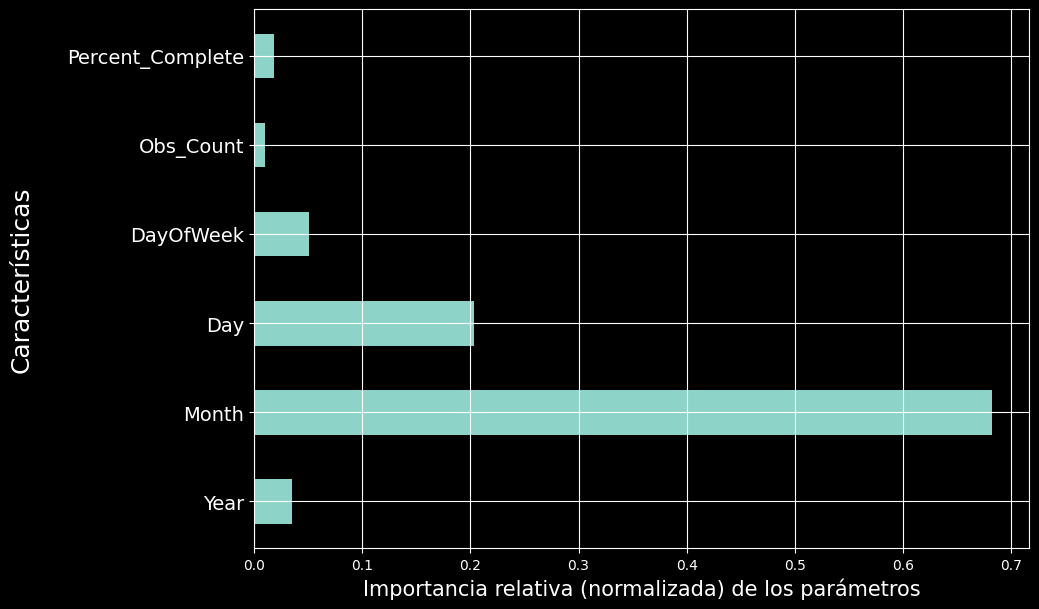

In [ ]:
print("Importancia relativa de las características:", tree_model.feature_importances_)

with plt.style.context('dark_background'):
    plt.figure(figsize=(10, 7))
    plt.grid(True)
    plt.yticks(range(len(X.columns)), X.columns, fontsize=14)
    plt.xlabel("Importancia relativa (normalizada) de los parámetros", fontsize=15)
    plt.ylabel("Características\n", fontsize=18)
    plt.barh(range(len(X.columns)), width=tree_model.feature_importances_, height=0.5)

17. Mínimos cuadrados (OLS) sobre el conjunto de datos de NO2 (2022-2023)

In [ ]:
import statsmodels.api as sm

In [ ]:
Xs = sm.add_constant(X)
stat_model = sm.OLS(Y, Xs)
stat_result = stat_model.fit()
print(stat_result.summary())

                            OLS Regression Results                            
Dep. Variable:                NO2_Max   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.5100
Date:                Fri, 18 Sep 2026   Prob (F-statistic):              0.801
Time:                        01:40:14   Log-Likelihood:                -2385.6
No. Observations:                 730   AIC:                             4785.
Df Residuals:                     723   BIC:                             4817.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const              631.5659    956.472  